In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load dataset
df = pd.read_csv('credit_risk_dataset.csv')

In [2]:
#Inspect structure
print("---Dataset Info ---")
df.info()

---Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [3]:
#Check for missing values
print("\n---Missing Values Count ---")
print(df.isnull().sum())


---Missing Values Count ---
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [4]:
#Check Target Balance(for recall justification)
print("\n ---Loan Status Distribution (0=Good, 1=Default) ---")
print(df['loan_status'].value_counts(normalize=True) * 100)


 ---Loan Status Distribution (0=Good, 1=Default) ---
loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64


In [5]:
#Stastitical Summary
print("\n--- Descriptive Statistics ---")
display(df.describe())


--- Descriptive Statistics ---


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [6]:
#Remove impossible outliers
df = df[df['person_age'] < 100]
df = df[df['person_emp_length'] < 60]

In [7]:
#Fill missing values
df['person_emp_length'] = df['person_emp_length'].fillna(0)
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

In [8]:
print(f"New dataset shape: {df.shape}")
print("\n--- Cleaned Stats ---")
print(df[['person_age', 'person_emp_length']].describe().loc[['min', 'max']])

New dataset shape: (31679, 12)

--- Cleaned Stats ---
     person_age  person_emp_length
min        20.0                0.0
max        94.0               41.0


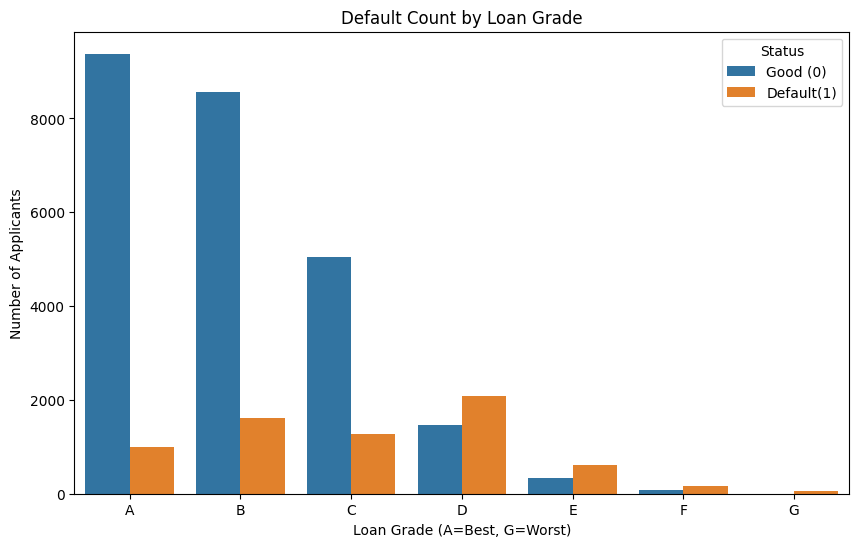

In [9]:
#Visualize Risk
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='loan_grade', hue='loan_status', order=['A','B','C','D','E','F','G'])
plt.title('Default Count by Loan Grade')
plt.xlabel('Loan Grade (A=Best, G=Worst)')
plt.ylabel('Number of Applicants')
plt.legend(title='Status', labels=['Good (0)', 'Default(1)'])
plt.show()

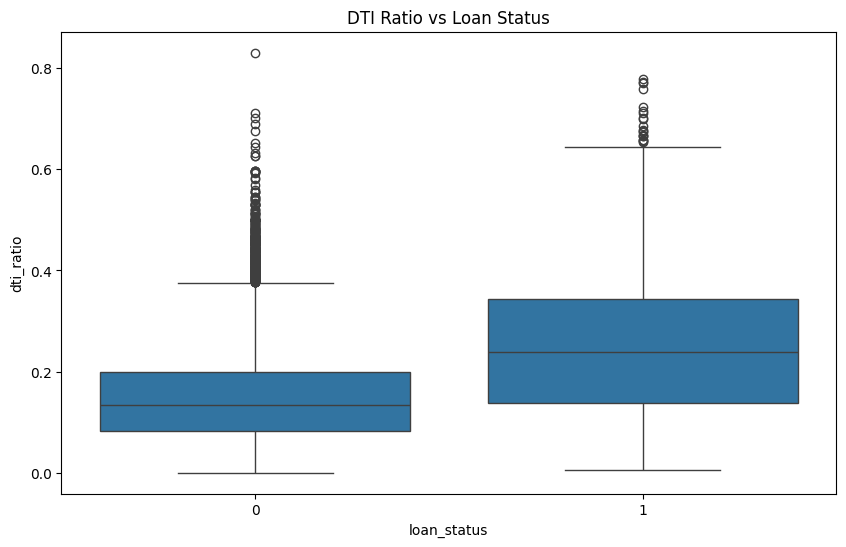

In [10]:
#DTI(debt to income) Ratio
df['dti_ratio'] = df['loan_amnt'] / df['person_income']

plt.figure(figsize=(10,6))
sns.boxplot(x='loan_status', y='dti_ratio', data=df)
plt.title('DTI Ratio vs Loan Status')
plt.show()

In [11]:
#One-Hot Encoding
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
df_final = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f"Features after encoding: {df_final.shape[1]}")
df_final.head()

Features after encoding: 24


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,dti_ratio,person_home_ownership_OTHER,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
1,21,9600,5.0,1000,11.14,0,0.10,2,0.104167,False,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,0.572917,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,0.534351,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,0.643382,False,...,True,False,False,False,True,False,False,False,False,True
5,21,9900,2.0,2500,7.14,1,0.25,2,0.252525,False,...,False,False,True,False,False,False,False,False,False,False


In [12]:
#Train-Test Split & Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_final.drop('loan_status', axis=1)
y = df_final['loan_status']

#Split 80% Training 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()

#TRAINING - learn from X_train to scale and scale it
X_train_scaled = scaler.fit_transform(X_train)

#Testing - use what was learned from X_train to scale X_test
X_test_scaled = scaler.transform(X_test)

print("Data split and scaled successfully.")

Data split and scaled successfully.


In [13]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the TRAINING data only
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print(f"Original training set shape: {y_train.value_counts().to_dict()}")
print(f"Resampled training set shape: {y_train_res.value_counts().to_dict()}")

Original training set shape: {0: 19883, 1: 5460}
Resampled training set shape: {0: 19883, 1: 19883}


K-Fold CV

In [14]:
# 1. Imports
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# 2. Initialize the models
# We define them here so the 'Audition' (K-Fold) has something to test
log_model = LogisticRegression(max_iter=1000)
rf_model = RandomForestClassifier(random_state=42)

# 3. Setup 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 4. Run the "Audition" using Recall
# Using X_train_res and y_train_res from your SMOTE step
log_cv_recall = cross_val_score(log_model, X_train_res, y_train_res, cv=kf, scoring='recall')
rf_cv_recall = cross_val_score(rf_model, X_train_res, y_train_res, cv=kf, scoring='recall')

print(f"Logistic Regression Avg Recall: {log_cv_recall.mean():.4f}")
print(f"Random Forest Avg Recall: {rf_cv_recall.mean():.4f}")

if rf_cv_recall.mean() > log_cv_recall.mean():
    print("Winner: Random Forest")
else:
    print("Winner: Logistic Regression")

Logistic Regression Avg Recall: 0.7911
Random Forest Avg Recall: 0.9070
Winner: Random Forest


In [15]:
#Random Forest

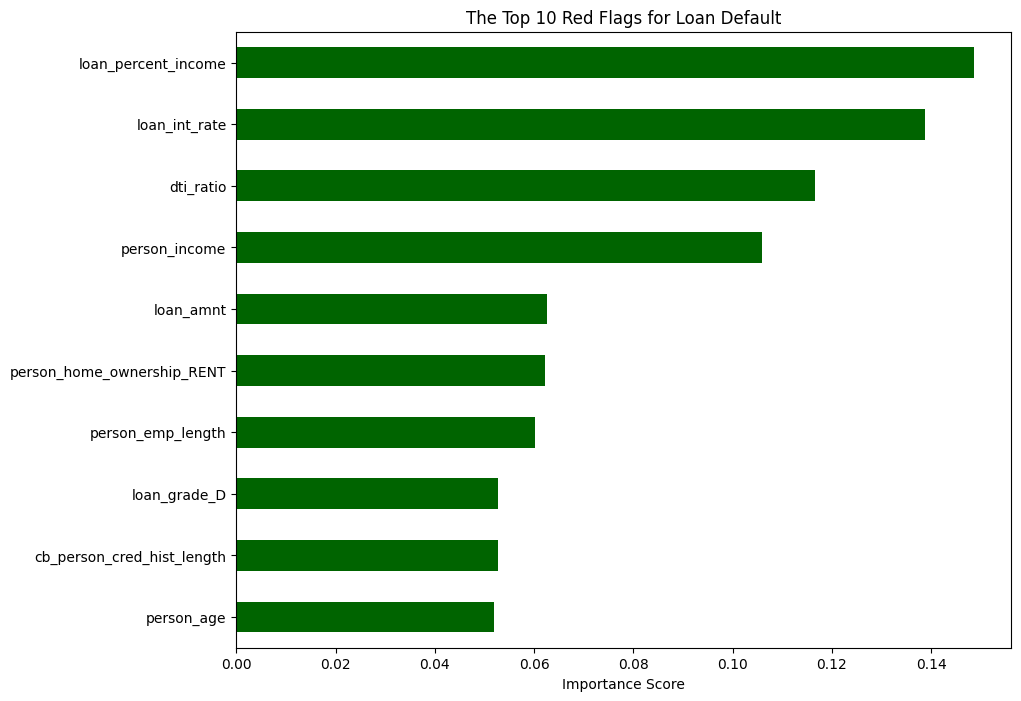

In [16]:
rf_model.fit(X_train_res, y_train_res)
importances = pd.Series(rf_model.feature_importances_, index=X.columns)

plt.figure(figsize=(10,8))
importances.nlargest(10).sort_values().plot(kind='barh', color='darkgreen')
plt.title('The Top 10 Red Flags for Loan Default')
plt.xlabel('Importance Score')
plt.show()

In [17]:
#Report
from sklearn.metrics import classification_report

final_preds = rf_model.predict(X_test_scaled)

print("--- FINAL PROJECT PERFORMANCE ---")
print(classification_report(y_test, final_preds))

--- FINAL PROJECT PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.93      0.98      0.96      4971
           1       0.90      0.75      0.82      1365

    accuracy                           0.93      6336
   macro avg       0.92      0.86      0.89      6336
weighted avg       0.93      0.93      0.93      6336



LLM & RAG

In [18]:
pip install langchain-community chromadb sentence-transformers openai


[notice] A new release of pip is available: 24.0 -> 26.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
policy_text = """
Bank Credit Policy 2024:
1. Applicants with a Debt-to-Income (DTI) ratio above 40% are considered high risk.
2. Employment history of less than 2 years requires a co-signer.
3. Loan grades E, F, and G are only eligible for secured loans.
4. If an applicant is a 'Renter' and has a DTI > 30%, extra scrutiny is required.
"""

with open("credit_policy.txt", "w") as f:
    f.write(policy_text)

In [20]:
pip install "numpy<2"


[notice] A new release of pip is available: 24.0 -> 26.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [21]:
import os
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import CharacterTextSplitter
from langchain_community.document_loaders import TextLoader

# 1. Load policy
loader = TextLoader("credit_policy.txt")
documents = loader.load()

# 2. Split
text_splitter = CharacterTextSplitter(chunk_size=150, chunk_overlap=10)
docs = text_splitter.split_documents(documents)

# 3. Create Embeddings
# We add model_kwargs to ensure it uses the CPU and doesn't look for a GPU
model_kwargs = {'device': 'cpu'}
encode_kwargs = {'normalize_embeddings': False}

embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2",
    model_kwargs=model_kwargs,
    encode_kwargs=encode_kwargs
)

# 4. Create Vectorstore
vectorstore = Chroma.from_documents(docs, embeddings)

print("✅ SUCCESS: Vector database is finally online!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ SUCCESS: Vector database is finally online!


In [22]:
import pandas as pd

def generate_audit_report(num_samples=10):
    report_data = []

    for i in range(num_samples):
        applicant_data = X_test.iloc[i]

        pred = rf_model.predict(X_test_scaled[i].reshape(1, -1))[0]
        status = "REJECT" if pred == 1 else "APPROVE"

        if pred == 1:
            query = f"Policy violation for DTI {applicant_data['dti_ratio']:.2f}"
            docs = vectorstore.similarity_search(query, k=1)
            reason = docs[0].page_content
        else:
            reason = "N/A - Meets Thresholds"

        report_data.append({
            "Applicant_ID": i,
            "Income": f"${applicant_data['person_income']:,}",
            "DTI": f"{applicant_data['dti_ratio']:.2%}",
            "Decision": status,
            "Policy_Reason": reason
        })

    return pd.DataFrame(report_data)

audit_df = generate_audit_report(10)
display(audit_df)

,Applicant_ID,Income,DTI,Decision,Policy_Reason
0,0,"$75,000",6.67%,APPROVE,N/A - Meets Thresholds
1,1,"$100,000",15.80%,APPROVE,N/A - Meets Thresholds
2,2,"$46,800",19.23%,APPROVE,N/A - Meets Thresholds
3,3,"$74,000",21.62%,APPROVE,N/A - Meets Thresholds
4,4,"$100,000",15.00%,APPROVE,N/A - Meets Thresholds
5,5,"$58,000",3.79%,APPROVE,N/A - Meets Thresholds
6,6,"$62,004",22.58%,APPROVE,N/A - Meets Thresholds
7,7,"$30,000",20.00%,REJECT,Bank Credit Policy 2024:\n1. Applicants with a...
8,8,"$71,000",21.13%,REJECT,Bank Credit Policy 2024:\n1. Applicants with a...
9,9,"$85,000",5.18%,APPROVE,N/A - Meets Thresholds


In [27]:
def test_rag_specifically_on_rejections(target_rejections=3):
    print(f"--- 🧪 FORCED REJECTION TEST (Goal: {target_rejections} hits) ---\n")
    found = 0
    
    for i in range(len(X_test)):
        applicant_data = X_test.iloc[i]
        pred = rf_model.predict(X_test_scaled[i].reshape(1, -1))[0]
        
        if pred == 1:
            found += 1
            print(f"Sample #{i}: [Income: ${applicant_data['person_income']:,} | DTI: {applicant_data['dti_ratio']:.2%}]")
            
            # Formulate and test the query
            query = f"Policy for DTI {applicant_data['dti_ratio']:.2f}"
            print(f"🔍 Query: '{query}'")
            
            docs = vectorstore.similarity_search(query, k=1)
            
            if docs:
                print(f"✅ RAG Success!")
                print(f"📄 Text: {docs[0].page_content[:200]}...")
            else:
                print(f"❌ RAG FAILED: No results found.")
            
            print("-" * 50)
            
        if found >= target_rejections:
            break

test_rag_specifically_on_rejections()

--- 🧪 FORCED REJECTION TEST (Goal: 3 hits) ---

Sample #7: [Income: $30,000 | DTI: 20.00%]
🔍 Query: 'Policy for DTI 0.20'
✅ RAG Success!
📄 Text: Bank Credit Policy 2024:
1. Applicants with a Debt-to-Income (DTI) ratio above 40% are considered high risk.
2. Employment history of less than 2 years requires a co-signer.
3. Loan grades E, F, and G...
--------------------------------------------------
Sample #8: [Income: $71,000 | DTI: 21.13%]
🔍 Query: 'Policy for DTI 0.21'
✅ RAG Success!
📄 Text: Bank Credit Policy 2024:
1. Applicants with a Debt-to-Income (DTI) ratio above 40% are considered high risk.
2. Employment history of less than 2 years requires a co-signer.
3. Loan grades E, F, and G...
--------------------------------------------------
Sample #16: [Income: $42,000 | DTI: 35.12%]
🔍 Query: 'Policy for DTI 0.35'
✅ RAG Success!
📄 Text: Bank Credit Policy 2024:
1. Applicants with a Debt-to-Income (DTI) ratio above 40% are considered high risk.
2. Employment history of less than 2 year

In [24]:
import joblib
# This creates the physical files app.py is looking for
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl') 
print("✅ Files are now physically in the folder!")

✅ Files are now physically in the folder!


In [25]:
print(list(X_train.columns))

['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'dti_ratio', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F', 'loan_grade_G', 'cb_person_default_on_file_Y']
